In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
import random
import warnings
import csv

from DCmatch import Match
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter("ignore", pd.errors.SettingWithCopyWarning)

In [2]:
folder = os.fsencode("seasons/bettingSeasons")
dataframes = []
for file in sorted(os.listdir(folder)):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        print(filename)
        df = pd.read_csv("seasons/bettingSeasons/" + filename)
        dataframes.append(df)

data = pd.concat(dataframes, axis=0)

1920-Copy1.csv
2021-Copy1.csv
2122-Copy1.csv
2223-Copy1.csv
2324-Copy1.csv
2425-Copy1.csv
E0 (1).csv


In [3]:
data = data[[
    "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "MaxH", "MaxD", "MaxA"
]]

In [7]:
data.describe()

,FTHG,FTAG,MaxH,MaxD,MaxA
count,2490.000000,2490.000000,2490.000000,2490.000000,2490.000000
mean,1.557028,1.318876,3.101189,4.524060,4.994863
std,1.321759,1.222005,2.419381,1.562595,5.052503
min,0.000000,0.000000,1.090000,3.100000,1.170000
25%,1.000000,0.000000,1.700000,3.650000,2.250000
50%,1.000000,1.000000,2.360000,4.000000,3.320000
75%,2.000000,2.000000,3.477500,4.750000,5.587500
max,9.000000,9.000000,22.000000,17.000000,50.000000


In [9]:
simpleData = data[["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG"]]
simpleData

,Date,HomeTeam,AwayTeam,FTHG,FTAG
0,09/08/2019,Liverpool,Norwich,4,1
1,10/08/2019,West Ham,Man City,0,5
2,10/08/2019,Bournemouth,Sheffield United,1,1
3,10/08/2019,Burnley,Southampton,3,0
4,10/08/2019,Crystal Palace,Everton,0,0
...,...,...,...,...,...
205,07/01/2026,Fulham,Chelsea,2,1
206,07/01/2026,Man City,Brighton,1,1
207,07/01/2026,Burnley,Man United,2,2
208,07/01/2026,Newcastle,Leeds,4,3


In [11]:
uniqueTeams = data["HomeTeam"].unique()

In [13]:
teamsIndex = {}
for i in range(len(uniqueTeams)):
    teamsIndex[uniqueTeams[i]] = i
teamsIndex

{'Liverpool': 0,
 'West Ham': 1,
 'Bournemouth': 2,
 'Burnley': 3,
 'Crystal Palace': 4,
 'Watford': 5,
 'Tottenham': 6,
 'Leicester': 7,
 'Newcastle': 8,
 'Man United': 9,
 'Arsenal': 10,
 'Aston Villa': 11,
 'Brighton': 12,
 'Everton': 13,
 'Norwich': 14,
 'Southampton': 15,
 'Man City': 16,
 'Sheffield United': 17,
 'Chelsea': 18,
 'Wolves': 19,
 'Fulham': 20,
 'West Brom': 21,
 'Leeds': 22,
 'Brentford': 23,
 "Nott'm Forest": 24,
 'Luton': 25,
 'Ipswich': 26,
 'Sunderland': 27}

In [15]:
dates = pd.to_datetime(simpleData["Date"], format="%d/%m/%Y")
simpleData["Week"] = (
    dates.dt.day
    + dates.dt.month * 12
    + dates.dt.year * 365
) // 7

In [17]:
from scipy.optimize import minimize
def phi(t):
    return np.exp(-0.03*t)

def logLikelihood(parameters, data):
    numTeams = int((len(parameters) - 2) // 2)
    
    attackStrengths = np.array(parameters[0:numTeams])
    defenceStrengths = np.array(parameters[numTeams:numTeams*2])
    
    homeAdv = parameters[-2]
    rho = parameters[-1]
    t = np.array(data["Week"])[-1]
    ll = 0

    for tk, row in data.iterrows():
        i = teamsIndex.get(row["HomeTeam"])
        j = teamsIndex.get(row["AwayTeam"])
        x = int(row["FTHG"])
        y = int(row["FTAG"])
        week = int(row["Week"])

        lamd = attackStrengths[i] * defenceStrengths[j] * homeAdv
        mu = attackStrengths[j] * defenceStrengths[i]

        ll += (np.log(Match.tauFunc(lamd, mu, rho, x, y) + 1e-7) - lamd + x*np.log(lamd) - mu + y*np.log(mu)) * phi(t - week)
    
    return -ll

In [19]:
from scipy.optimize import minimize
np.random.seed(1008)
def getNewEstimates(results: pd.DataFrame):
    rng = np.random.default_rng(123)
    init_att = rng.uniform(0.8, 2, size=len(uniqueTeams))
    init_def = rng.uniform(0.8, 1.3, size=len(uniqueTeams))
    init_home = 1.1
    init_rho = 0.0

    init = np.concatenate([init_att, init_def, [init_home, init_rho]])

    bounds = [(1e-6, None)] * (2*len(uniqueTeams)) + [(1e-6, None), (-0.99, 0.99)]

    result = minimize(
        logLikelihood,
        init,
        args=(results.tail(n=400),),
        bounds=bounds,
        options={'maxiter': 10000, 'disp': True},
    )
    return result.x

In [21]:
# currentEstimates = getNewEstimates(simpleData)

In [23]:
teamsLookup = {v: k for k, v in teamsIndex.items()}

In [26]:
homeTeams = ["Man City", "Brentford", "Bournemouth", "Everton", "Crystal Palace", "Fulham", "Newcastle", "Burnley"]
awayTeams = ["Brighton", "Sunderland", "Tottenham", "Wolves", "Aston Villa", "Chelsea", "Leeds", "Man United"]
for i in range(len(homeTeams)):
    match = Match(currentEstimates[teamsIndex.get(homeTeams[i])], currentEstimates[teamsIndex.get(homeTeams[i]) + 28], currentEstimates[teamsIndex.get(awayTeams[i])], currentEstimates[teamsIndex.get(awayTeams[i]) + 28], currentEstimates[-2], currentEstimates[-1], 8)
    probs = 1 / np.array(match.getOutcomeProbs())
    print(f"{homeTeams[i]}  {probs[0]}  -  {probs[1]}  -  {probs[2]}  {awayTeams[i]}")

NameError: name 'currentEstimates' is not defined

In [28]:
estimatesAtTimeT = []
for i in range(380, len(data["HomeTeam"]), 10):
    estimatesAtTimeT.append(getNewEstimates(simpleData.head(n=i)))
    print(f"Estimates at t={i} done")

with open("newEstimatesOvernight.csv", "w+") as my_csv:
    csvWriter = csv.writer(my_csv,delimiter=',')
    csvWriter.writerows(estimatesAtTimeT)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           58     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.81420D+02    |proj g|=  1.32524D+01

At iterate    1    f=  3.62620D+02    |proj g|=  2.23982D+00

At iterate    2    f=  3.54284D+02    |proj g|=  4.80869D+01

At iterate    3    f=  3.44909D+02    |proj g|=  3.90977D+01

At iterate    4    f=  3.25749D+02    |proj g|=  2.38626D+01

At iterate    5    f=  3.18634D+02    |proj g|=  5.73140D+00

At iterate    6    f=  3.17166D+02    |proj g|=  2.08834D+00

At iterate    7    f=  3.16785D+02    |proj g|=  6.64130D-01

At iterate    8    f=  3.16734D+02    |proj g|=  8.97739D-01

At iterate    9    f=  3.16719D+02    |proj g|=  8.16732D-01

At iterate   10    f=  3.16711D+02    |proj g|=  3.20841D-01

At iterate   11    f=  3.16710D+02    |proj g|=  1.35913D-01

At iterate   12    f=  3.16709D+02    |proj g|=  5.73266D-02

At iterate   13    f=  3.1

KeyboardInterrupt: 

In [25]:
newEstimates = []

with open("newEstimatesOvernight.csv", newline="") as my_csv:
    csvReader = csv.reader(my_csv)
    for row in csvReader:
        newEstimates.append([float(x) for x in row])

In [27]:
strengthsOverTime = [[row[i] for row in newEstimates] for i in range(len(newEstimates[0]))]

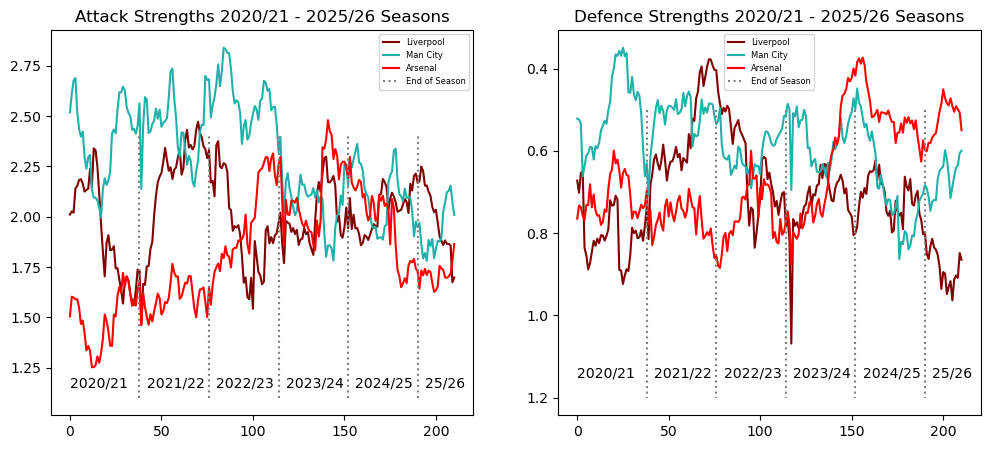

In [29]:
teamsLookup = {v: k for k, v in teamsIndex.items()}

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(strengthsOverTime[teamsIndex.get("Liverpool")], label="Liverpool", color="maroon")
ax[0].plot(strengthsOverTime[teamsIndex.get("Man City")], label="Man City", color="lightseagreen")
ax[0].plot(strengthsOverTime[teamsIndex.get("Arsenal")], label="Arsenal", color="red")
ax[0].set_title("Attack Strengths 2020/21 - 2025/26 Seasons")
ax[0].vlines(38, 1.1, 2.4, color="grey", linestyle="dotted", label="End of Season")
ax[0].vlines(76, 1.1, 2.4, color="grey", linestyle="dotted")
ax[0].vlines(114, 1.1, 2.4, color="grey", linestyle="dotted")
ax[0].vlines(152, 1.1, 2.4, color="grey", linestyle="dotted")
ax[0].vlines(190, 1.1, 2.4, color="grey", linestyle="dotted")
ax[0].legend(prop={'size': 6})
ax[0].text(0, 1.15, "2020/21")
ax[0].text(42, 1.15, "2021/22")
ax[0].text(80, 1.15, "2022/23")
ax[0].text(118, 1.15, "2023/24")
ax[0].text(156, 1.15, "2024/25")
ax[0].text(194, 1.15, "25/26")

ax[1].plot(strengthsOverTime[teamsIndex.get("Liverpool")+28], label="Liverpool", color="maroon")
ax[1].plot(strengthsOverTime[teamsIndex.get("Man City")+28], label="Man City", color="lightseagreen")
ax[1].plot(strengthsOverTime[teamsIndex.get("Arsenal")+28], label="Arsenal", color="red")
ax[1].set_title("Defence Strengths 2020/21 - 2025/26 Seasons")
ax[1].invert_yaxis()
ax[1].vlines(38, 0.5, 1.2, color="grey", linestyle="dotted", label="End of Season")
ax[1].vlines(76, 0.5, 1.2, color="grey", linestyle="dotted")
ax[1].vlines(114, 0.5, 1.2, color="grey", linestyle="dotted")
ax[1].vlines(152, 0.5, 1.2, color="grey", linestyle="dotted")
ax[1].vlines(190, 0.5, 1.2, color="grey", linestyle="dotted")
ax[1].legend(prop={'size': 6})
ax[1].text(0, 1.15, "2020/21")
ax[1].text(42, 1.15, "2021/22")
ax[1].text(80, 1.15, "2022/23")
ax[1].text(118, 1.15, "2023/24")
ax[1].text(156, 1.15, "2024/25")
ax[1].text(194, 1.15, "25/26")
fig.savefig("top3.jpg")

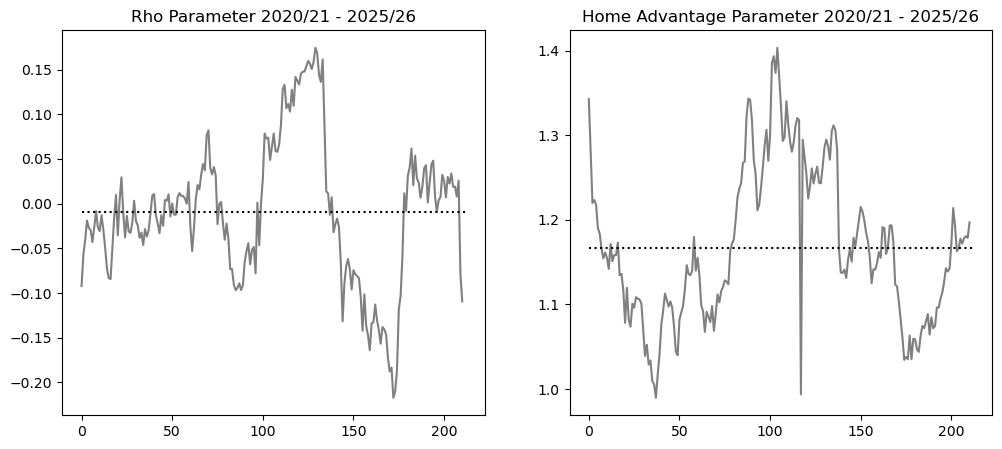

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(strengthsOverTime[-1], color="grey")
ax[0].hlines(np.mean(strengthsOverTime[-1]), 0, 212, linestyle="dotted", color="black")
ax[0].set_title("Rho Parameter 2020/21 - 2025/26")
ax[1].plot(strengthsOverTime[-2], color="grey")
ax[1].hlines(np.mean(strengthsOverTime[-2]), 0, 212, linestyle="dotted", color="black")
ax[1].set_title("Home Advantage Parameter 2020/21 - 2025/26")
fig.savefig("paramsP")

In [33]:
teamStrengths = [[] for i in range(58)]

for i in range(len(simpleData["AwayTeam"])):
    if i < 380:
        for j in range(58):
            teamStrengths[j].append(0)
    else:
        for j in range(58):
            teamStrengths[j].append(strengthsOverTime[j][(i-380) // 10])

In [35]:
attack = teamStrengths[0:28]
defence = teamStrengths[28:56]
homeAdvantage = teamStrengths[-2]
rho = teamStrengths[-1]

In [37]:
home_idx = data["HomeTeam"].map(teamsIndex).to_numpy()
away_idx = data["AwayTeam"].map(teamsIndex).to_numpy()

In [39]:
t = np.arange(len(data["HomeTeam"]))

In [41]:
homeAttacks = []
homeDefences = []
awayAttacks = []
awayDefences = []

for i in range(len(data["HomeTeam"])):
    homeAttacks.append(attack[home_idx[i]][i])
    homeDefences.append(defence[home_idx[i]][i])
    awayAttacks.append(attack[away_idx[i]][i])
    awayDefences.append(defence[away_idx[i]][i])

homeProbs = []
drawProbs = []
awayProbs = []

for i in range(len(data["HomeTeam"])):
    thisMatch = Match(homeAttacks[i], homeDefences[i], awayAttacks[i], awayDefences[i], homeAdvantage[i], rho[i], 8)
    outcomes = thisMatch.getOutcomeProbs()
    homeProbs.append(outcomes[0])
    drawProbs.append(outcomes[1])
    awayProbs.append(outcomes[2])



data["attackH"]  = homeAttacks
data["defenceH"] = homeDefences
data["attackA"]  = awayAttacks
data["defenceA"] = awayDefences
data["rho"] = rho
data["homeAdv"] = homeAdvantage
data["homeProb"] = homeProbs
data["drawProb"] = drawProbs
data["awayProb"] = awayProbs
data["FairHomeOdds"] = 1 / data["homeProb"]
data["FairDrawOdds"] = 1 / data["drawProb"]
data["FairAwayOdds"] = 1 / data["awayProb"]

In [43]:
bettingFrame = data.tail(n=2110)
bettingFrame["HomeWin"] = np.where(bettingFrame["FTR"] == "H", 1, 0)
bettingFrame["Draw"] = np.where(bettingFrame["FTR"] == "D", 1, 0)
bettingFrame["AwayWin"] = np.where(bettingFrame["FTR"] == "A", 1, 0)
bettingFrame.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,MaxH,MaxD,MaxA,attackH,...,homeAdv,homeProb,drawProb,awayProb,FairHomeOdds,FairDrawOdds,FairAwayOdds,HomeWin,Draw,AwayWin
0,12/09/2020,Fulham,Arsenal,0,3,A,6.55,4.55,1.60,1.077867,...,1.342738,0.256029,0.272854,0.471117,3.905806,3.664968,2.122614,0,0,1
1,12/09/2020,Crystal Palace,Southampton,1,0,H,3.36,3.36,2.50,0.725293,...,1.342738,0.237064,0.303230,0.459706,4.218275,3.297823,2.175303,1,0,0
2,12/09/2020,Liverpool,Leeds,4,3,H,1.35,6.50,10.75,2.010702,...,1.342738,0.676324,0.195212,0.128464,1.478581,5.122624,7.784309,1,0,0
3,12/09/2020,West Ham,Newcastle,0,2,A,2.24,3.70,3.60,1.332293,...,1.342738,0.559395,0.244834,0.195771,1.787646,4.084399,5.108004,0,0,1
4,13/09/2020,West Brom,Leicester,0,3,A,4.00,3.82,2.04,0.999085,...,1.342738,0.274875,0.282907,0.442218,3.638018,3.534736,2.261326,0,0,1


In [45]:
bettingFrame["impH_raw"] = 1 / bettingFrame["MaxH"]
bettingFrame["impD_raw"] = 1 / bettingFrame["MaxD"]
bettingFrame["impA_raw"] = 1 / bettingFrame["MaxA"]

In [47]:
bettingFrame["overround"] = (
    bettingFrame["impH_raw"] +
    bettingFrame["impD_raw"] +
    bettingFrame["impA_raw"]
)

bettingFrame["impH"] = bettingFrame["impH_raw"] / bettingFrame["overround"]
bettingFrame["impD"] = bettingFrame["impD_raw"] / bettingFrame["overround"]
bettingFrame["impA"] = bettingFrame["impA_raw"] / bettingFrame["overround"]

In [49]:
bettingFrame["homeOdds"] = 1/bettingFrame.impH
bettingFrame["drawOdds"] = 1/bettingFrame.impD
bettingFrame["awayOdds"] = 1/bettingFrame.impA

In [51]:
bettingFrame.tail()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,MaxH,MaxD,MaxA,attackH,...,impH_raw,impD_raw,impA_raw,overround,impH,impD,impA,homeOdds,drawOdds,awayOdds
205,07/01/2026,Fulham,Chelsea,2,1,H,3.50,3.70,2.12,1.395373,...,0.285714,0.270270,0.471698,1.027683,0.278018,0.262990,0.458992,3.596889,3.802426,2.178687
206,07/01/2026,Man City,Brighton,1,1,D,1.40,5.50,8.50,2.008553,...,0.714286,0.181818,0.117647,1.013751,0.704597,0.179352,0.116051,1.419251,5.575630,8.616883
207,07/01/2026,Burnley,Man United,2,2,D,5.00,4.00,1.75,0.963505,...,0.200000,0.250000,0.571429,1.021429,0.195804,0.244755,0.559441,5.107143,4.085714,1.787500
208,07/01/2026,Newcastle,Leeds,4,3,H,1.73,4.10,5.50,1.590797,...,0.578035,0.243902,0.181818,1.003755,0.575872,0.242990,0.181138,1.736497,4.115397,5.520654
209,08/01/2026,Arsenal,Liverpool,0,0,D,1.64,4.33,5.60,1.864074,...,0.609756,0.230947,0.178571,1.019274,0.598226,0.226580,0.175195,1.671610,4.413458,5.707937


In [53]:
bettingFrame["Brier"] = (bettingFrame["homeProb"] - bettingFrame["HomeWin"])**2 + (bettingFrame["drawProb"] - bettingFrame["Draw"])**2 + (bettingFrame["awayProb"] - bettingFrame["AwayWin"])**2

In [55]:
eps = 1e-10

pH = np.clip(bettingFrame["homeProb"], eps, 1 - eps)
pD = np.clip(bettingFrame["drawProb"], eps, 1 - eps)
pA = np.clip(bettingFrame["awayProb"], eps, 1 - eps)

bettingFrame["LogLoss"] = -(
    bettingFrame["HomeWin"] * np.log(pH)
  + bettingFrame["Draw"]    * np.log(pD)
  + bettingFrame["AwayWin"] * np.log(pA)
)

In [57]:
bettingFrame["histLogLoss"] = -(
    bettingFrame["HomeWin"] * np.log(0.434123)
  + bettingFrame["Draw"]    * np.log(0.231280)
  + bettingFrame["AwayWin"] * np.log(0.334597)
)

In [59]:
np.sum(bettingFrame.Brier)/len(np.array(bettingFrame.Brier))

0.5892824124282784

In [61]:
np.sum(bettingFrame.LogLoss)/len(np.array(bettingFrame.LogLoss))

1.029933913919124

In [63]:
bettingFrame[["HomeWin", "Draw", "AwayWin"]].describe()

,HomeWin,Draw,AwayWin
count,2110.000000,2110.000000,2110.000000
mean,0.434123,0.231280,0.334597
std,0.495759,0.421751,0.471961
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000


In [65]:
bettingFrame["histBrier"] = (0.434123 - bettingFrame["HomeWin"])**2 + (0.231280 - bettingFrame["Draw"])**2 + (0.334597 - bettingFrame["AwayWin"])**2

In [67]:
np.sum(bettingFrame.histBrier)/len(np.array(bettingFrame.histBrier))

0.6460915073787582

In [69]:
np.sum(bettingFrame.histLogLoss)/len(np.array(bettingFrame.histLogLoss))

1.067193337480911

In [71]:
bettingFrame["oddsBrier"] = (bettingFrame["impH"] - bettingFrame["HomeWin"])**2 + (bettingFrame["impD"] - bettingFrame["Draw"])**2 + (bettingFrame["impA"] - bettingFrame["AwayWin"])**2

In [73]:
np.sum(bettingFrame.oddsBrier)/len(np.array(bettingFrame.oddsBrier))

0.5694878560611414

In [75]:
eps = 1e-10

pH = np.clip(bettingFrame["impH"], eps, 1 - eps)
pD = np.clip(bettingFrame["impD"], eps, 1 - eps)
pA = np.clip(bettingFrame["impA"], eps, 1 - eps)

bettingFrame["oddsLogLoss"] = -(
    bettingFrame["HomeWin"] * np.log(pH)
  + bettingFrame["Draw"]    * np.log(pD)
  + bettingFrame["AwayWin"] * np.log(pA)
)

In [77]:
np.sum(bettingFrame.oddsLogLoss)/len(np.array(bettingFrame.oddsLogLoss))

0.9598224339826054

In [79]:
bettingFrame["ValueRatioHome"] = bettingFrame["MaxH"] * bettingFrame["homeProb"]
bettingFrame["ValueRatioDraw"] = bettingFrame["MaxD"] * bettingFrame["drawProb"]
bettingFrame["ValueRatioAway"] = bettingFrame["MaxA"] * bettingFrame["awayProb"]

In [81]:
threshold = 1.1

value_cols = ['ValueRatioHome', 'ValueRatioAway', 'ValueRatioDraw']

# Identify best outcome per row
best = bettingFrame[value_cols].idxmax(axis=1)
max_value = bettingFrame[value_cols].max(axis=1)

# Reset bets
bettingFrame[['HomeBet', 'AwayBet', 'DrawBet']] = 0

bettingFrame.loc[
    (max_value > threshold) & (best == 'ValueRatioHome'),
    'HomeBet'
] = 1

bettingFrame.loc[
    (max_value > threshold) & (best == 'ValueRatioAway'),
    'AwayBet'
] = 1

bettingFrame.loc[
    (max_value > threshold) & (best == 'ValueRatioDraw'),
    'DrawBet'
] = 1

In [83]:
bankroll = 1000
kellyFraction = 0.25

bettingFrame["kellyHomeFraction"] = bettingFrame["HomeBet"] * (bettingFrame["homeProb"] * (bettingFrame["MaxH"] - 1) - (1-bettingFrame["homeProb"])) / ((bettingFrame["MaxH"] - 1)) * kellyFraction
bettingFrame["kellyDrawFraction"] = bettingFrame["DrawBet"] * (bettingFrame["drawProb"] * (bettingFrame["MaxD"] - 1) - (1-bettingFrame["drawProb"])) / ((bettingFrame["MaxD"] - 1)) * kellyFraction
bettingFrame["kellyAwayFraction"] = bettingFrame["AwayBet"] * (bettingFrame["awayProb"] * (bettingFrame["MaxA"] - 1) - (1-bettingFrame["awayProb"])) / ((bettingFrame["MaxA"] - 1)) * kellyFraction

bettingFrame["kellyHome"] = bettingFrame["HomeBet"] * (bettingFrame["homeProb"] * (bettingFrame["MaxH"] - 1) - (1-bettingFrame["homeProb"])) / ((bettingFrame["MaxH"] - 1))
bettingFrame["kellyDraw"] = bettingFrame["DrawBet"] * (bettingFrame["drawProb"] * (bettingFrame["MaxD"] - 1) - (1-bettingFrame["drawProb"])) / ((bettingFrame["MaxD"] - 1))
bettingFrame["kellyAway"] = bettingFrame["AwayBet"] * (bettingFrame["awayProb"] * (bettingFrame["MaxA"] - 1) - (1-bettingFrame["awayProb"])) / ((bettingFrame["MaxA"] - 1))

In [85]:
bettingFrame["flatProfit"] = bettingFrame["HomeWin"] * bettingFrame["HomeBet"] * bettingFrame["MaxH"] + bettingFrame["AwayWin"] * bettingFrame["AwayBet"] * bettingFrame["MaxA"] - (bettingFrame["HomeBet"] + bettingFrame["AwayBet"])

In [87]:
starting_bankroll = 100
bankroll = starting_bankroll

bankroll_history = []
stake_history = []
pnl_history = []

kellyBank = 100
kellyBankroll = []
kellyStakes = []
kellyPnL = []

for _, row in bettingFrame.iterrows():

    stake = 0.0
    pnl = 0.0

    kellyStake = 0.0
    kellyPnLs = 0.0
    
    # Home bet
    if row['HomeBet'] == 1:
        stake = bankroll * row['kellyHomeFraction']
        kellyStake = kellyBank * row["kellyHome"]
        if row['HomeWin'] == 1:
            pnl = stake * (row['MaxH'] - 1)
            kellyPnLs = kellyStake * (row["MaxH"] - 1)
        else:
            pnl = -stake
            kellyPnLs = -kellyStake

    # Draw bet
    elif row['DrawBet'] == 1:
        stake = bankroll * row['kellyDrawFraction']
        kellyStake = kellyBank * row["kellyDraw"]
        if row['Draw'] == 1:
            pnl = stake * (row['MaxD'] - 1)
            kellyPnLs = kellyStake * (row["MaxD"] - 1)
        else:
            pnl = -stake
            kellyPnLs = -kellyStake
    
    # Away bet
    elif row['AwayBet'] == 1:
        stake = bankroll * row['kellyAwayFraction']
        kellyStake = kellyBank * row["kellyAway"]
        if row['AwayWin'] == 1:
            pnl = stake * (row['MaxA'] - 1)
            kellyPnLs = kellyStake * (row["MaxA"] - 1)
        else:
            pnl = -stake
            kellyPnLs = -kellyStake

    bankroll += pnl
    kellyBank += kellyPnLs
    
    bankroll_history.append(bankroll)
    stake_history.append(stake)
    pnl_history.append(pnl)

    kellyBankroll.append(kellyBank)
    kellyStakes.append(kellyStake)
    kellyPnL.append(kellyPnLs)
    
bettingFrame['Bankroll'] = bankroll_history
bettingFrame['Stake'] = stake_history
bettingFrame['PnL'] = pnl_history

bettingFrame["kellyBankroll"] = kellyBankroll
bettingFrame["kellyStake"] = kellyStakes
bettingFrame["kellyPnL"] = kellyPnL

In [89]:
bettingFrame = bettingFrame.reset_index()
bettingFrame.drop(["index"], axis=1)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,MaxH,MaxD,MaxA,attackH,...,kellyHome,kellyDraw,kellyAway,flatProfit,Bankroll,Stake,PnL,kellyBankroll,kellyStake,kellyPnL
0,12/09/2020,Fulham,Arsenal,0,3,A,6.55,4.55,1.60,1.077867,...,0.121980,0.0,-0.000000,-1.0,96.950492,3.049508,-3.049508,8.780197e+01,1.219803e+01,-1.219803e+01
1,12/09/2020,Crystal Palace,Southampton,1,0,H,3.36,3.36,2.50,0.725293,...,-0.000000,0.0,0.099510,-1.0,94.538607,2.411885,-2.411885,7.906480e+01,8.737170e+00,-8.737170e+00
2,12/09/2020,Liverpool,Leeds,4,3,H,1.35,6.50,10.75,2.010702,...,-0.000000,0.0,0.039075,-1.0,93.615079,0.923529,-0.923529,7.597533e+01,3.089473e+00,-3.089473e+00
3,12/09/2020,West Ham,Newcastle,0,2,A,2.24,3.70,3.60,1.332293,...,0.204068,-0.0,-0.000000,-1.0,88.839118,4.775961,-4.775961,6.047119e+01,1.550413e+01,-1.550413e+01
4,13/09/2020,West Brom,Leicester,0,3,A,4.00,3.82,2.04,0.999085,...,0.000000,0.0,-0.000000,0.0,88.839118,0.000000,0.000000,6.047119e+01,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2105,07/01/2026,Fulham,Chelsea,2,1,H,3.50,3.70,2.12,1.395373,...,0.000000,0.0,-0.000000,0.0,3.681241,0.000000,0.000000,3.275409e-21,0.000000e+00,0.000000e+00
2106,07/01/2026,Man City,Brighton,1,1,D,1.40,5.50,8.50,2.008553,...,-0.000000,0.0,0.024777,-1.0,3.658439,0.022802,-0.022802,3.194256e-21,8.115354e-23,-8.115354e-23
2107,07/01/2026,Burnley,Man United,2,2,D,5.00,4.00,1.75,0.963505,...,0.038867,0.0,-0.000000,-1.0,3.622890,0.035549,-0.035549,3.070103e-21,1.241527e-22,-1.241527e-22
2108,07/01/2026,Newcastle,Leeds,4,3,H,1.73,4.10,5.50,1.590797,...,-0.000000,0.0,0.025412,-1.0,3.599874,0.023016,-0.023016,2.992087e-21,7.801642e-23,-7.801642e-23


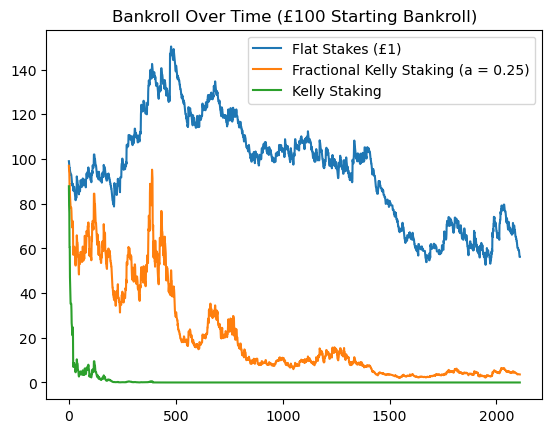

In [91]:
fig, ax = plt.subplots()
ax.plot(bettingFrame["flatProfit"].cumsum()+100, label="Flat Stakes (£1)")
ax.plot(bettingFrame["Bankroll"], label="Fractional Kelly Staking (a = 0.25)")
ax.plot(bettingFrame["kellyBankroll"], label="Kelly Staking")
ax.set_title("Bankroll Over Time (£100 Starting Bankroll)")
ax.legend()

fig.savefig("stakeComparison.jpg")

In [64]:
bettingFrame.head()

,index,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,MaxH,MaxD,MaxA,...,kellyHomeFraction,kellyDrawFraction,kellyAwayFraction,flatProfit,Bankroll,Stake,PnL,flatBankroll,flatStake,flatPnL
0,0,12/09/2020,Fulham,Arsenal,0,3,A,6.55,4.55,1.60,...,0.030495,0.0,-0.000000,-1.0,96.950492,3.049508,-3.049508,98.000000,2.000000,-2.000000
1,1,12/09/2020,Crystal Palace,Southampton,1,0,H,3.36,3.36,2.50,...,-0.000000,0.0,0.024877,-1.0,94.538607,2.411885,-2.411885,96.040000,1.960000,-1.960000
2,2,12/09/2020,Liverpool,Leeds,4,3,H,1.35,6.50,10.75,...,-0.000000,0.0,0.009769,-1.0,93.615079,0.923529,-0.923529,94.119200,1.920800,-1.920800
3,3,12/09/2020,West Ham,Newcastle,0,2,A,2.24,3.70,3.60,...,0.051017,-0.0,-0.000000,-1.0,88.839118,4.775961,-4.775961,92.236816,1.882384,-1.882384
4,4,13/09/2020,West Brom,Leicester,0,3,A,4.00,3.82,2.04,...,0.008292,0.0,-0.000000,-1.0,88.102494,0.736624,-0.736624,90.392080,1.844736,-1.844736


In [125]:
bettingFrame.kellyStake.sum()

179.12303358469487

In [127]:
bettingFrame["kellyPnL"].sum()

-100.00000000000001

In [129]:
-100/ 179.12

-0.5582849486377847

In [133]:
np.var(bettingFrame.kellyPnL)

0.5146873329053812

In [101]:
cleanProfits = [x for x in bettingFrame.flatProfit if x!=0]

In [103]:
np.var(cleanProfits)

2.9207589244174192

In [107]:
np.mean(cleanProfits)

-0.030707778556412057

In [ ]:
bettingFrame.HomeBet.sum() + bettingFrame.DrawBet.sum() + bettingFrame.AwayBet.sum()

In [111]:
bettingFrame.columns

Index(['index', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'MaxH',
       'MaxD', 'MaxA', 'attackH', 'defenceH', 'attackA', 'defenceA', 'rho',
       'homeAdv', 'homeProb', 'drawProb', 'awayProb', 'FairHomeOdds',
       'FairDrawOdds', 'FairAwayOdds', 'HomeWin', 'Draw', 'AwayWin',
       'impH_raw', 'impD_raw', 'impA_raw', 'overround', 'impH', 'impD', 'impA',
       'homeOdds', 'drawOdds', 'awayOdds', 'Brier', 'LogLoss', 'histLogLoss',
       'histBrier', 'oddsBrier', 'oddsLogLoss', 'ValueRatioHome',
       'ValueRatioDraw', 'ValueRatioAway', 'HomeBet', 'AwayBet', 'DrawBet',
       'kellyHomeFraction', 'kellyDrawFraction', 'kellyAwayFraction',
       'kellyHome', 'kellyDraw', 'kellyAway', 'flatProfit', 'Bankroll',
       'Stake', 'PnL', 'kellyBankroll', 'kellyStake', 'kellyPnL'],
      dtype='object')

In [ ]:
bettingFrame.HomeBet.sum() + bettingFrame.DrawBet.sum() + bettingFrame.AwayBet.sum()

In [213]:
import csv


with open("profitsMLE.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(cleanProfits)